In [97]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from sklearn.metrics import recall_score
import time
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.naive_bayes import GaussianNB
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
import joblib


In [98]:
#   Step 2: Dataset Loading & Exploratory Data Analysis

# 2.1  Load & Inspect

# 1. Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# 2. Shape
print("Shape:", df.shape)

# 3. Information
print("\n--- INFO ---")
print(df.info())

# 4. Description
print("\n--- DESCRIBE ---")
print(df.describe())

# 5. First 10 rows
print("\n--- HEAD(10) ---")
print(df.head(10))


# 6. Check TotalCharges data type
print("\nTotalCharges datatype before:", df["TotalCharges"].dtype)

# Convert whitespace rows to NaN and then to float64
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].replace(" ", pd.NA),
    errors="coerce"
)

# Fill missing values with 0
df["TotalCharges"] = df["TotalCharges"].fillna(0).astype("float64")

print("TotalCharges datatype after:", df["TotalCharges"].dtype)


# 7. Class balance
print("\n--- CHURN CLASS BALANCE ---")
print(df["Churn"].value_counts())

# Percentage
churn_percentage = df["Churn"].value_counts(normalize=True) * 100
print("\n--- CHURN PERCENTAGE ---")
print(churn_percentage)

Shape: (7043, 21)

--- INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessB

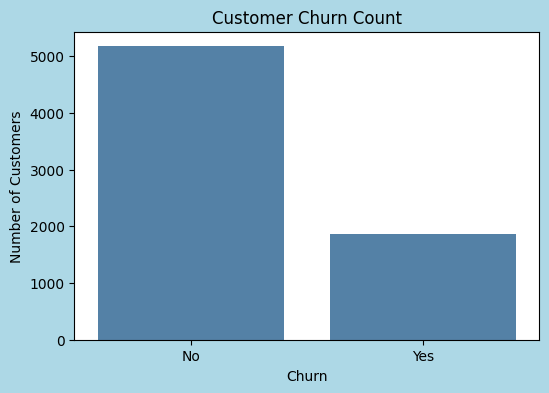

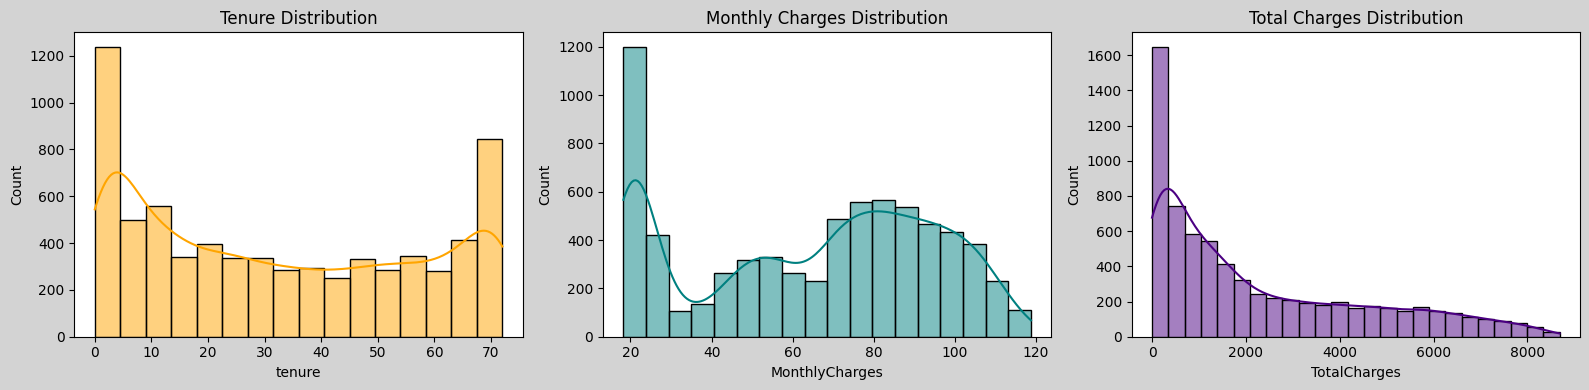

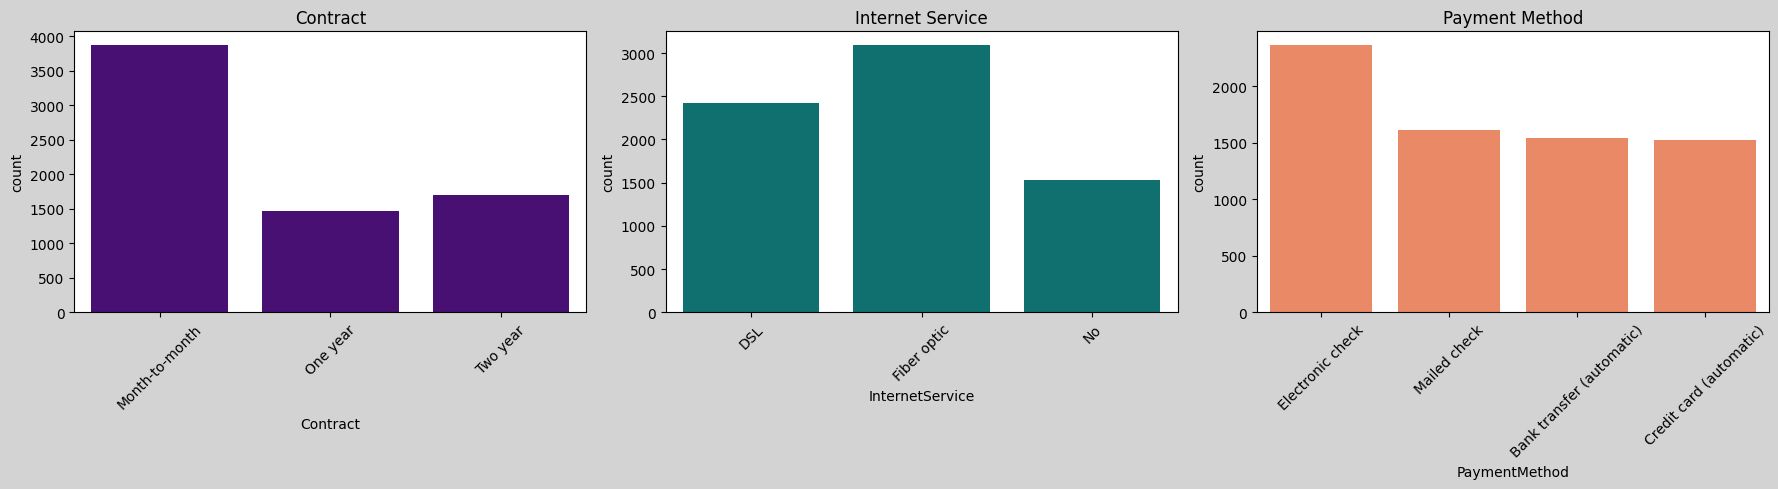

In [99]:
# 2.2 Univariate Analysis

# Target variable - Churn 
plt.figure(figsize=(6,4), facecolor="lightblue") 

sns.countplot(data=df, x="Churn", color="steelblue") 

plt.title("Customer Churn Count") 
plt.xlabel("Churn") 
plt.ylabel("Number of Customers") 
plt.show()


# Histograms
fig, axes = plt.subplots(1, 3, figsize=(16,4),facecolor="lightgrey")

sns.histplot(df["tenure"], kde=True, ax=axes[0],color="orange")
axes[0].set_title("Tenure Distribution")

sns.histplot(df["MonthlyCharges"], kde=True, ax=axes[1],color="Teal")
axes[1].set_title("Monthly Charges Distribution")

sns.histplot(df["TotalCharges"], kde=True, ax=axes[2],color="Indigo")
axes[2].set_title("Total Charges Distribution")

plt.tight_layout()
plt.show()


# Countplots for categorical features
fig, axes = plt.subplots(1, 3, figsize=(18,5),facecolor="lightgrey")

sns.countplot(data=df, x="Contract", ax=axes[0],color="Indigo")
axes[0].set_title("Contract")

sns.countplot(data=df, x="InternetService", ax=axes[1],color="teal")
axes[1].set_title("Internet Service")

sns.countplot(data=df, x="PaymentMethod", ax=axes[2],color="coral")
axes[2].set_title("Payment Method")

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

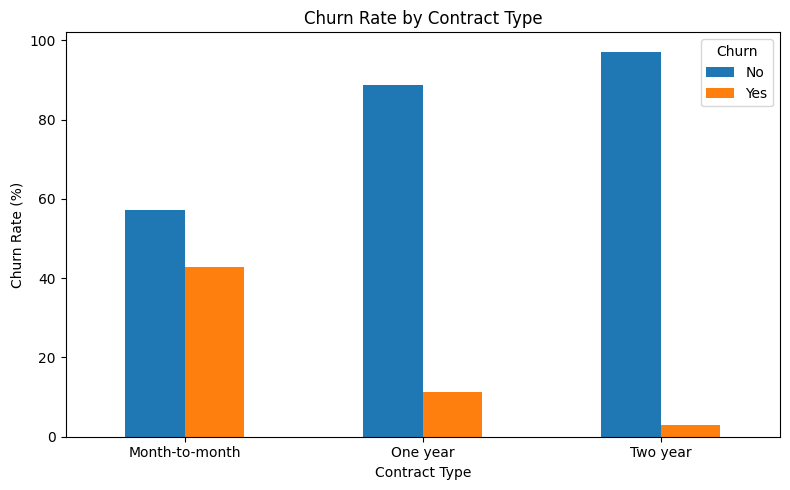

In [100]:
# 2.3 Bivariate Analysis 

# 1. Churn Rate by Contract
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn"],
    normalize="index"
) * 100

contract_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

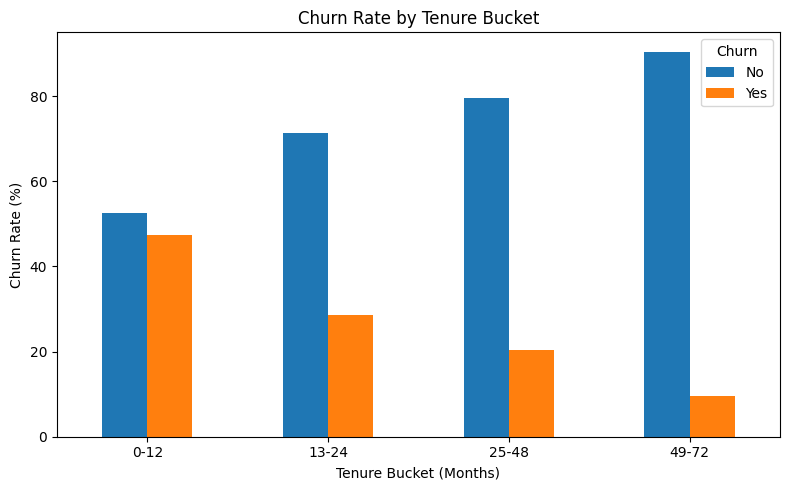

In [101]:
# 2. Churn Rate by Tenure Bucket
# Create tenure buckets
df["TenureBucket"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 24, 48, 72],
    labels=["0-12", "13-24", "25-48", "49-72"]
)

# Calculate churn rate
tenure_churn = pd.crosstab(
    df["TenureBucket"],
    df["Churn"],
    normalize="index"
) * 100

tenure_churn.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Churn Rate by Tenure Bucket")
plt.xlabel("Tenure Bucket (Months)")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")
plt.tight_layout()
plt.show()

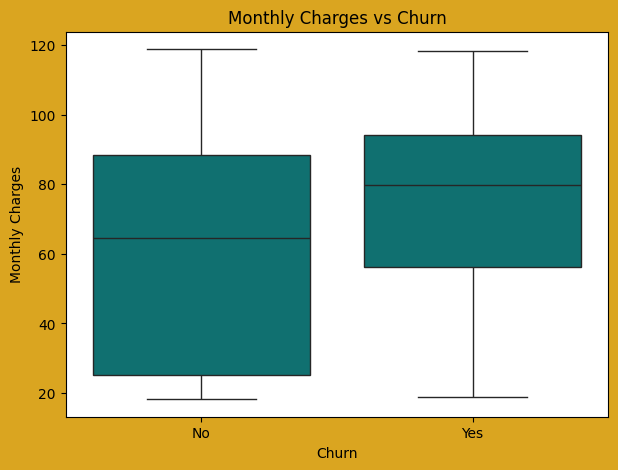

In [102]:
# 3. MonthlyCharges vs Churn — Boxplot

plt.figure(figsize=(7,5), facecolor="goldenrod")

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges",
    color="teal"
)

plt.title("Monthly Charges vs Churn")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

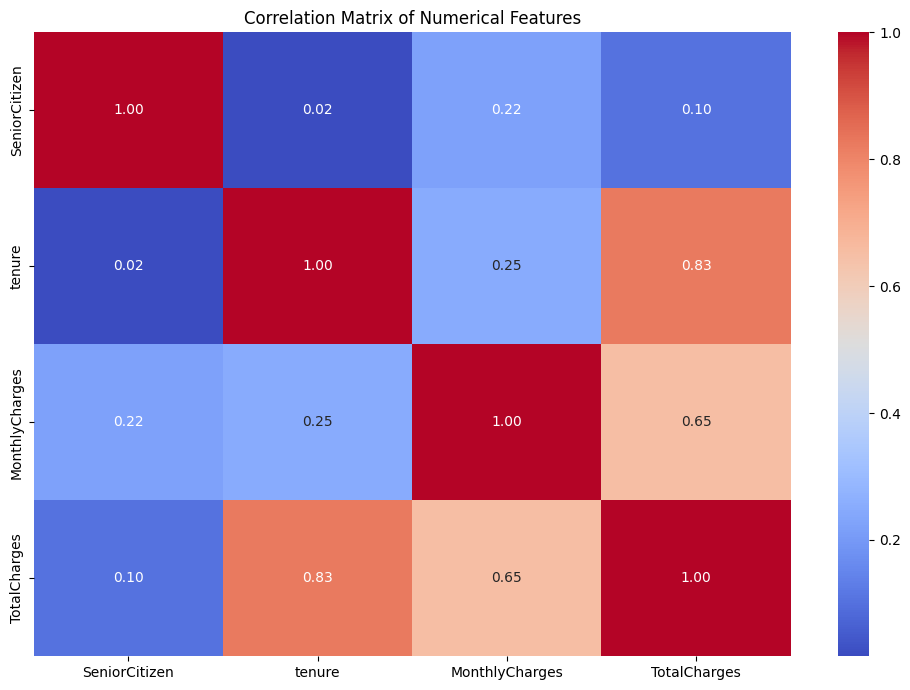

In [103]:
# 4. Correlation Heatmap
# Select numerical columns
numeric_df = df.select_dtypes(include="number")

# Correlation matrix
corr = numeric_df.corr()

plt.figure(figsize=(10,7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [104]:
#   Step 3: Data Preprocessing & Feature Engineering

# 3.1 Drop & Clean

# Drop customerID
if "customerID" in df.columns:
    df.drop("customerID", axis=1, inplace=True)

# Convert TotalCharges into numeric
df["TotalCharges"] = pd.to_numeric(
    df["TotalCharges"].replace(" ", np.nan),
    errors="coerce"
)

# Fill missing values with median
df["TotalCharges"] = df["TotalCharges"].fillna(
    df["TotalCharges"].median()
)

# Check result
print("TotalCharges datatype:", df["TotalCharges"].dtype)
print("TotalCharges null values:", df["TotalCharges"].isnull().sum())
print("Shape:", df.shape)

TotalCharges datatype: float64
TotalCharges null values: 0
Shape: (7043, 21)


In [105]:
# 3.2 Feature Engineering

# 1. Create tenure_group
df["tenure_group"] = pd.cut(
    df["tenure"],
    bins=[-1, 12, 36, 60, 72],
    labels=["New", "Mid", "Senior", "Loyal"]
)

# 2. Count number of services
service_cols = [
    "OnlineSecurity",
    "OnlineBackup",
    "DeviceProtection",
    "TechSupport",
    "StreamingTV",
    "StreamingMovies"
]

df["num_services"] = (df[service_cols] == "Yes").sum(axis=1)

# 3. Create AutoPay feature
df["AutoPay"] = df["PaymentMethod"].str.contains(
    "automatic",
    case=False,
    na=False
).astype(int)

# Check result
print(df[[
    "tenure",
    "tenure_group",
    "num_services",
    "AutoPay"
]].head())

   tenure tenure_group  num_services  AutoPay
0       1          New             1        0
1      34          Mid             2        0
2       2          New             2        0
3      45       Senior             3        1
4       2          New             0        0


In [106]:
# 3.3 Encoding

# Binary columns: Yes/No → 1/0
binary_cols = [
    "Partner",
    "Dependents",
    "PhoneService",
    "PaperlessBilling",
    "Churn"
]

for col in binary_cols:
    df[col] = df[col].map({
        "Yes": 1,
        "No": 0
    })


# One-Hot Encoding
one_hot_cols = [
    "InternetService",
    "Contract",
    "PaymentMethod"
]

df = pd.get_dummies(
    df,
    columns=one_hot_cols,
    drop_first=True,
    dtype=int
)


# Encode tenure_group
tenure_mapping = {
    "New": 0,
    "Mid": 1,
    "Senior": 2,
    "Loyal": 3
}

df["tenure_group"] = (
    df["tenure_group"]
    .astype(str)
    .map(tenure_mapping)
)


# Check result
print(df.head())
print("\nShape:", df.shape)

   gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
0  Female              0        1           0       1             0   
1    Male              0        0           0      34             1   
2    Male              0        0           0       2             1   
3    Male              0        0           0      45             0   
4  Female              0        0           0       2             1   

      MultipleLines OnlineSecurity OnlineBackup DeviceProtection  ...  \
0  No phone service             No          Yes               No  ...   
1                No            Yes           No              Yes  ...   
2                No            Yes          Yes               No  ...   
3  No phone service            Yes           No              Yes  ...   
4                No             No           No               No  ...   

  tenure_group num_services AutoPay  InternetService_Fiber optic  \
0            0            1       0                            0  

In [107]:
# 3.4 Train-Test Split

X = df.drop("Churn", axis=1)
y = df["Churn"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)


# Scaling
scale_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "num_services"
]

scaler = StandardScaler()

X_train[scale_cols] = scaler.fit_transform(
    X_train[scale_cols]
)

X_test[scale_cols] = scaler.transform(
    X_test[scale_cols]
)

print("\nScaling completed successfully!")

X_train: (5634, 27)
X_test: (1409, 27)
y_train: (5634,)
y_test: (1409,)

Scaling completed successfully!


In [108]:
# 3.5  Handle Class Imbalance

# Convert remaining categorical columns into numbers
X_train = pd.get_dummies(X_train, drop_first=True, dtype=int)
X_test = pd.get_dummies(X_test, drop_first=True, dtype=int)

# Make train and test columns same
X_train, X_test = X_train.align(
    X_test,
    join="left",
    axis=1,
    fill_value=0
)

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE only on training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Class distribution before SMOTE
print("Before SMOTE:")
print(y_train.value_counts())

# Class distribution after SMOTE
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Check shapes
print("\nBefore SMOTE:", X_train.shape)
print("After SMOTE :", X_train_smote.shape)

Before SMOTE:
Churn
0    4139
1    1495
Name: count, dtype: int64

After SMOTE:
Churn
0    4139
1    4139
Name: count, dtype: int64

Before SMOTE: (5634, 36)
After SMOTE : (8278, 36)


In [109]:
# 3.6  Train-Test Split

# Features and target
X = df.drop("Churn", axis=1)
y = df["Churn"]

# 80% Train, 20% Test
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

# Print shapes
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5634, 27)
X_test shape: (1409, 27)
y_train shape: (5634,)
y_test shape: (1409,)


In [110]:
# Step 4: Model Building — KNN & Naive Bayes

# 4.1 KNN Baseline (k=5)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Make X_test columns exactly same as training data
X_test = X_test.reindex(
    columns=X_train_smote.columns,
    fill_value=0
)

# Create KNN model
knn = KNeighborsClassifier(n_neighbors=5)

# Train model
knn.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_knn = knn.predict(X_test)

# Probability for AUC-ROC
y_prob_knn = knn.predict_proba(X_test)[:, 1]

# Report metrics
print("KNN (k=5) Results")
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))
print("AUC-ROC  :", roc_auc_score(y_test, y_prob_knn))

KNN (k=5) Results
Accuracy : 0.7317246273953159
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
AUC-ROC  : 0.5010178511457283


k = 1 F1 Score = 0.2781
k = 3 F1 Score = 0.0106
k = 5 F1 Score = 0.0
k = 7 F1 Score = 0.0
k = 9 F1 Score = 0.0
k = 11 F1 Score = 0.0
k = 15 F1 Score = 0.0

Best k: 1
Best F1 Score: 0.2781


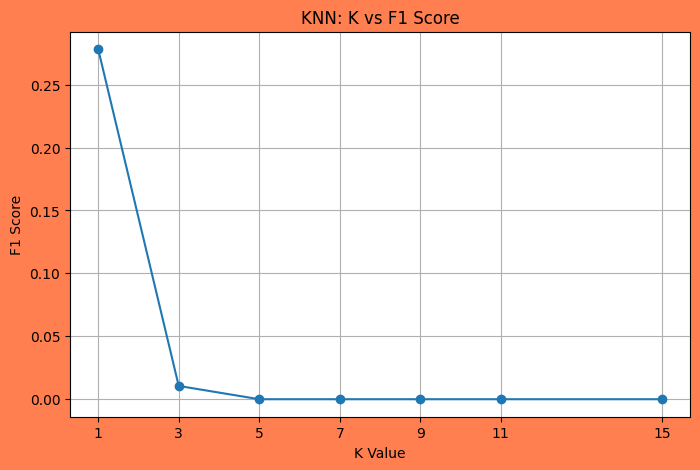

In [111]:
# 4.2 KNN - Tune k

# K values
k_values = [1, 3, 5, 7, 9, 11, 15]

f1_scores = []

# Test each k
for k in k_values:

    knn_model = KNeighborsClassifier(n_neighbors=k)

    # Train
    knn_model.fit(X_train_smote, y_train_smote)

    # Prediction on validation/test set
    y_pred = knn_model.predict(X_test)

    # F1 Score
    f1 = f1_score(y_test, y_pred)

    f1_scores.append(f1)

# Print results
for k, score in zip(k_values, f1_scores):
    print("k =", k, "F1 Score =", round(score, 4))

# Find best k
best_k = k_values[f1_scores.index(max(f1_scores))]

print("\nBest k:", best_k)
print("Best F1 Score:", round(max(f1_scores), 4))

# Plot
plt.figure(figsize=(8, 5),facecolor="coral")
plt.plot(k_values, f1_scores, marker="o")

plt.xlabel("K Value")
plt.ylabel("F1 Score")
plt.title("KNN: K vs F1 Score")

plt.xticks(k_values)
plt.grid()
plt.show()

Optimal k: 1


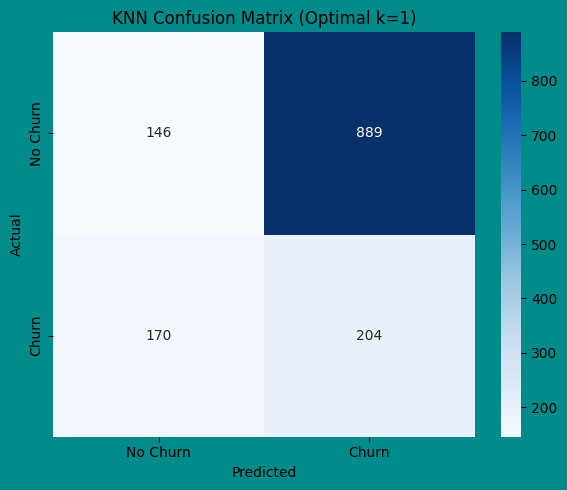

In [112]:
#4.3 Re-train KNN with Optimal K

# Use best k from previous step
print("Optimal k:", best_k)

# Create KNN with optimal k
knn_best = KNeighborsClassifier(n_neighbors=best_k)

# Train model
knn_best.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_best = knn_best.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

# Heatmap
plt.figure(figsize=(6, 5),facecolor="darkcyan")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"KNN Confusion Matrix (Optimal k={best_k})")

plt.tight_layout()
plt.show()

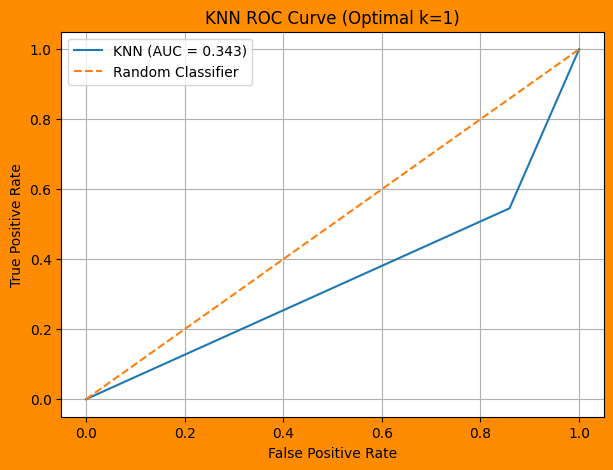

Optimal k: 1
AUC-ROC: 0.343


In [113]:
# 4.4 ROC Curve and AUC


# Probability prediction
y_prob_best = knn_best.predict_proba(X_test)[:, 1]

# AUC
auc_score = roc_auc_score(y_test, y_prob_best)

# ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_best)

# Plot ROC Curve
plt.figure(figsize=(7, 5),facecolor="darkorange")

plt.plot(
    fpr,
    tpr,
    label=f"KNN (AUC = {auc_score:.3f})"
)

# Random classifier line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"KNN ROC Curve (Optimal k={best_k})")
plt.legend()
plt.grid()
plt.show()

# Report AUC
print("Optimal k:", best_k)
print("AUC-ROC:", round(auc_score, 3))

SVM Baseline Results (C=1)
Accuracy : 0.7345635202271115
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
AUC-ROC  : 0.4990338164251208


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


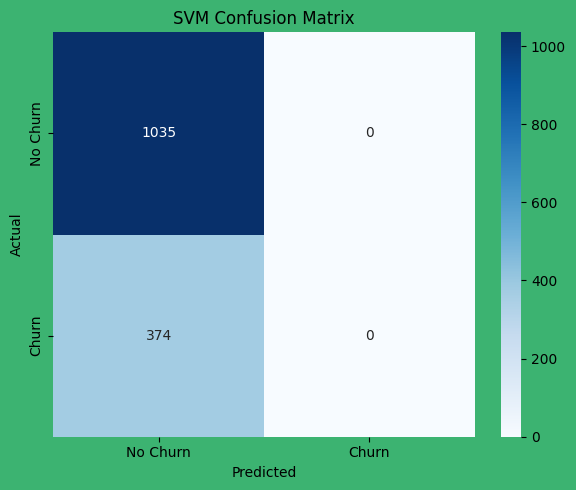


C Tuning Results
C = 0.1 F1 Score = 0.7803
C = 1 F1 Score = 0.7948
C = 10 F1 Score = 0.8071
C = 100 F1 Score = 0.8015

Best C: 10
Best CV F1: 0.8071


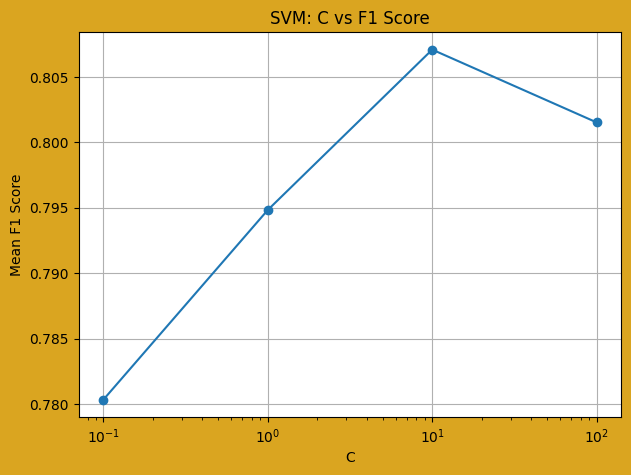


Final SVM Test Results
Best C   : 10
Accuracy : 0.7345635202271115
Precision: 0.0
Recall   : 0.0
F1 Score : 0.0
AUC-ROC  : 0.4990338164251208


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


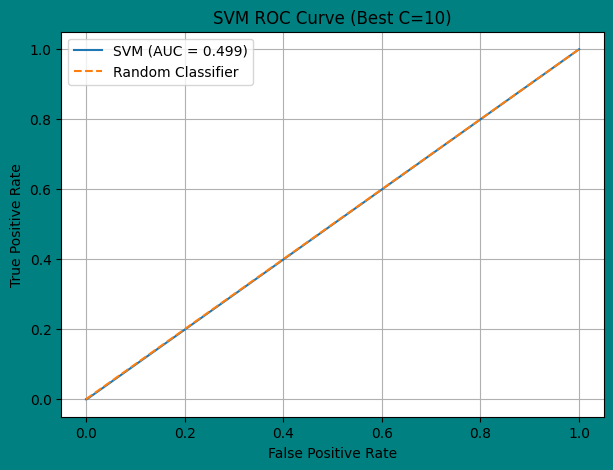

Final AUC-ROC: 0.499


In [ ]:
#   Step 5: Model Building — SVM & Decision Tree

# 5.1 Support Vector Machine (SVM)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)


# 1. Train SVM Baseline


svm_model = SVC(
    kernel="rbf",
    C=1,
    gamma="scale",
    probability=True,
    random_state=42
)

svm_model.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_svm = svm_model.predict(X_test)
y_prob_svm = svm_model.predict_proba(X_test)[:, 1]


# 2. Report Metrics


print("SVM Baseline Results (C=1)")

print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))
print("AUC-ROC  :", roc_auc_score(y_test, y_prob_svm))



# 3. Confusion Matrix


cm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(6, 5),facecolor="mediumseagreen")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SVM Confusion Matrix")

plt.tight_layout()
plt.show()


# 4. Tune C using 3-Fold Cross Validation


C_values = [0.1, 1, 10, 100]

f1_scores = []

for c in C_values:

    svm = SVC(
        kernel="rbf",
        C=c,
        gamma="scale",
        probability=True,
        random_state=42
    )

    scores = cross_val_score(
        svm,
        X_train_smote,
        y_train_smote,
        cv=3,
        scoring="f1"
    )

    f1_scores.append(scores.mean())


# Print C and F1
print("\nC Tuning Results")

for c, score in zip(C_values, f1_scores):
    print("C =", c, "F1 Score =", round(score, 4))


# Select best C
best_C = C_values[f1_scores.index(max(f1_scores))]

print("\nBest C:", best_C)
print("Best CV F1:", round(max(f1_scores), 4))


# 5. Plot C vs F1


plt.figure(figsize=(7, 5),facecolor="goldenrod")

plt.plot(
    C_values,
    f1_scores,
    marker="o"
)

plt.xlabel("C")
plt.ylabel("Mean F1 Score")
plt.title("SVM: C vs F1 Score")
plt.xscale("log")
plt.xticks(C_values)
plt.grid()

plt.show()


# 6. Re-train with Best C


final_svm = SVC(
    kernel="rbf",
    C=best_C,
    gamma="scale",
    probability=True,
    random_state=42
)

final_svm.fit(
    X_train_smote,
    y_train_smote
)

# Final prediction
y_pred_final = final_svm.predict(X_test)

# Final probability
y_prob_final = final_svm.predict_proba(X_test)[:, 1]


# 7. Final Test Metrics


print("\nFinal SVM Test Results")

print("Best C   :", best_C)
print("Accuracy :", accuracy_score(y_test, y_pred_final))
print("Precision:", precision_score(y_test, y_pred_final))
print("Recall   :", recall_score(y_test, y_pred_final))
print("F1 Score :", f1_score(y_test, y_pred_final))
print("AUC-ROC  :", roc_auc_score(y_test, y_prob_final))



# 8. Final ROC Curve


fpr, tpr, thresholds = roc_curve(
    y_test,
    y_prob_final
)

auc_score = roc_auc_score(
    y_test,
    y_prob_final
)

plt.figure(figsize=(7, 5),facecolor="teal")

plt.plot(
    fpr,
    tpr,
    label=f"SVM (AUC = {auc_score:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title(f"SVM ROC Curve (Best C={best_C})")
plt.legend()
plt.grid()

plt.show()

print("Final AUC-ROC:", round(auc_score, 3))

Decision Tree Results
Accuracy : 0.44215755855216465
Precision: 0.27312775330396477
Recall   : 0.6631016042780749
F1 Score : 0.3868954758190328
AUC-ROC  : 0.4627166808752486


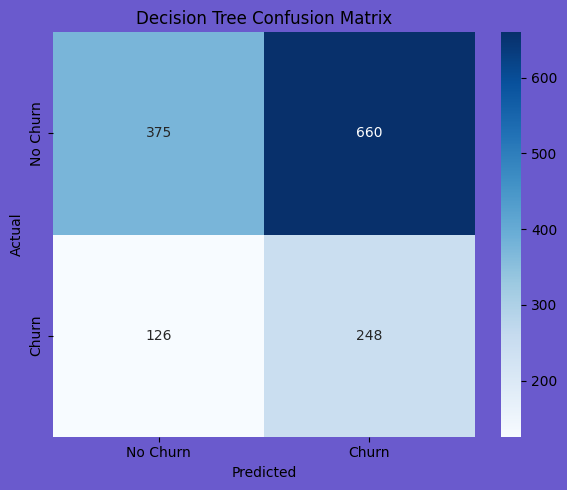

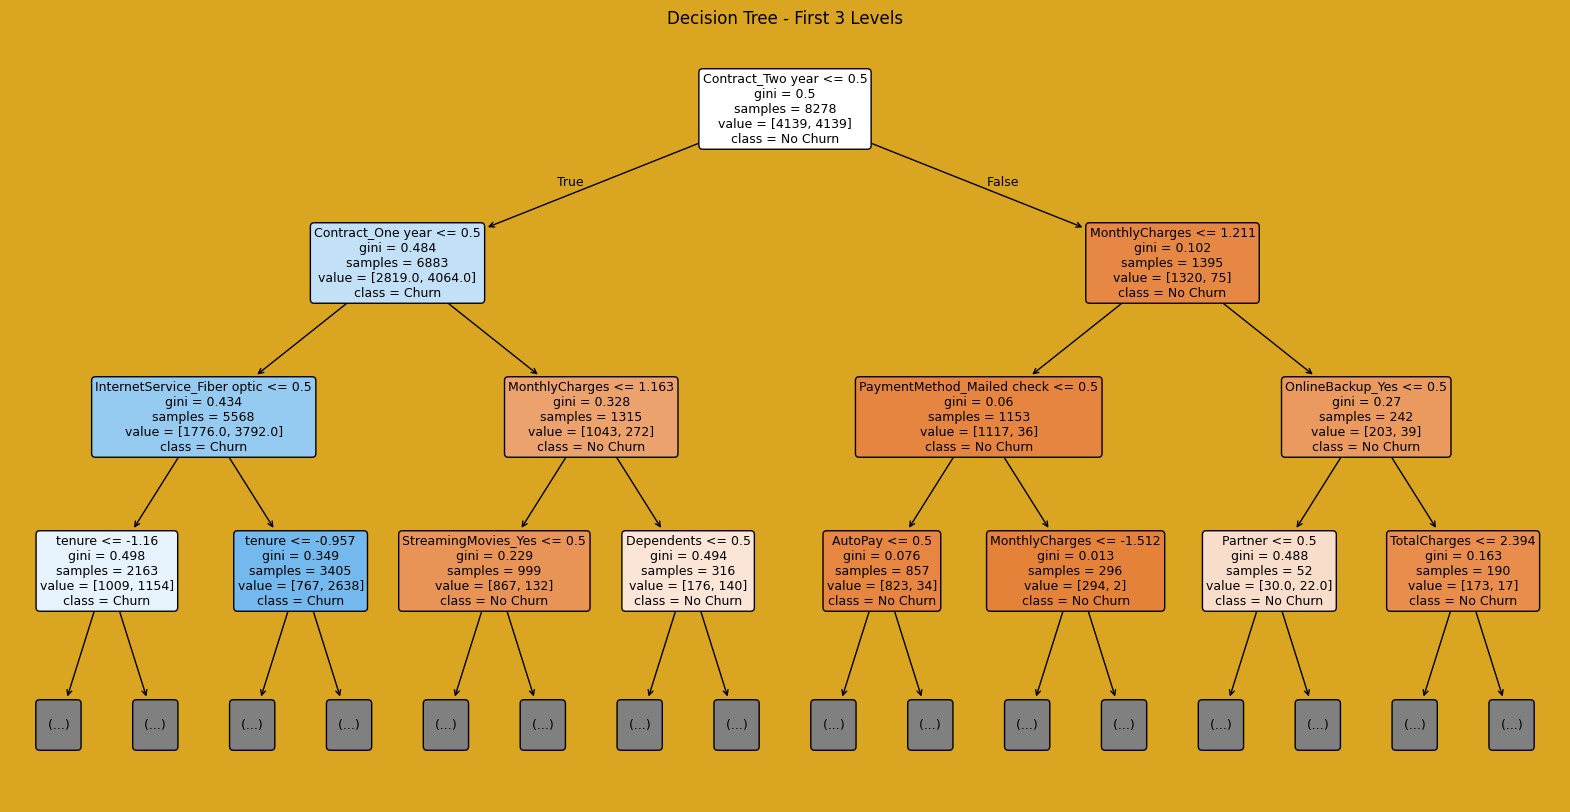

Root Split Feature: Contract_Two year
Decision Tree Depth Tuning
Depth = 3 F1 Score = 0.7811
Depth = 4 F1 Score = 0.7726
Depth = 5 F1 Score = 0.7707
Depth = 6 F1 Score = 0.7929
Depth = 7 F1 Score = 0.7967
Depth = 8 F1 Score = 0.7946
Depth = None F1 Score = 0.7798

Best Depth: 7
Best F1 Score: 0.7967


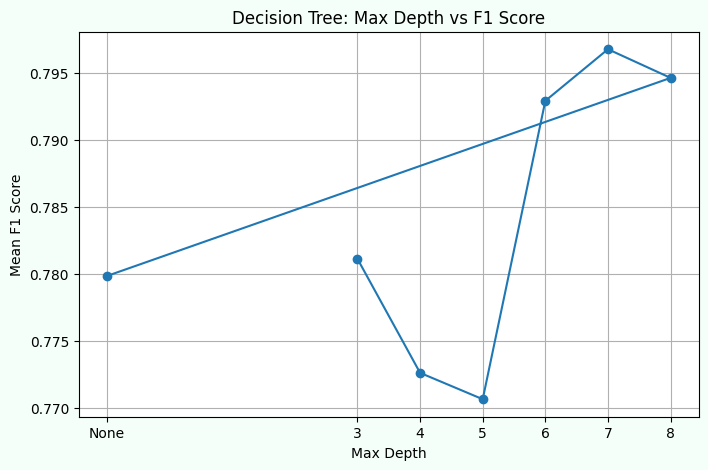

Top 15 Important Features:
                            Feature  Importance
14                Contract_Two year    0.342986
13                Contract_One year    0.245571
3                            tenure    0.098695
11      InternetService_Fiber optic    0.079021
6                    MonthlyCharges    0.074861
7                      TotalCharges    0.026583
28                  TechSupport_Yes    0.025967
22               OnlineSecurity_Yes    0.023187
2                        Dependents    0.014667
9                      num_services    0.011713
16   PaymentMethod_Electronic check    0.008039
29  StreamingTV_No internet service    0.007168
32              StreamingMovies_Yes    0.006819
1                           Partner    0.006371
0                     SeniorCitizen    0.004988


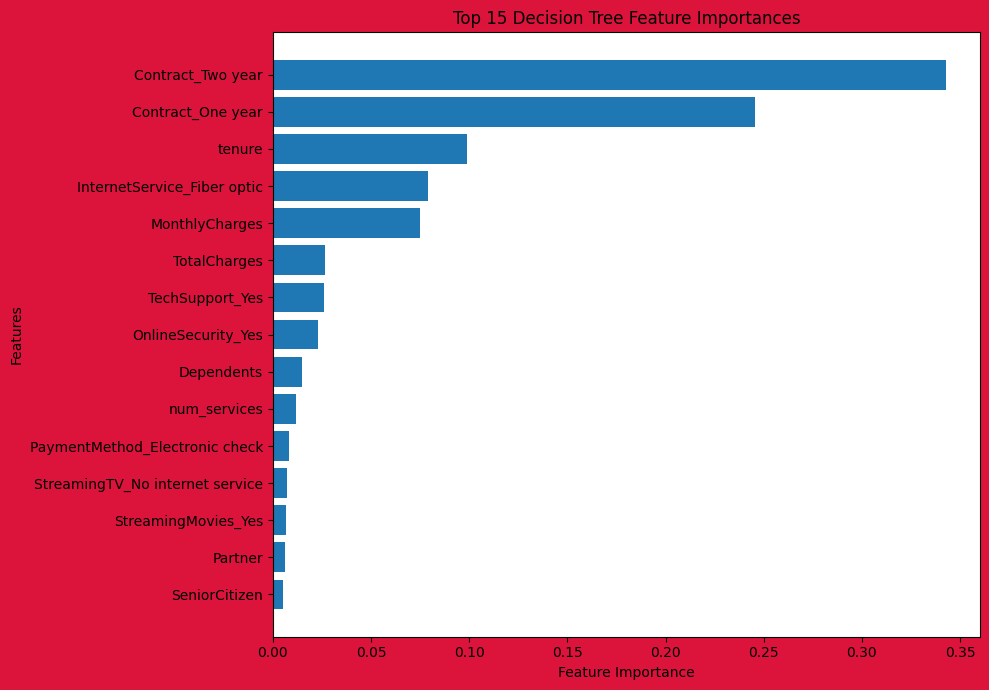

In [115]:
# 5.2 Decision Tree Classifier

# 1. Train + All Metrics + Confusion Matrix
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)


# Create Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=5,
    class_weight="balanced",
    random_state=42
)

# Train
dt_model.fit(X_train_smote, y_train_smote)

# Prediction
y_pred_dt = dt_model.predict(X_test)

# Probability
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Metrics
print("Decision Tree Results")

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("AUC-ROC  :", roc_auc_score(y_test, y_prob_dt))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6, 5),facecolor="slateblue")

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.tight_layout()
plt.show()

# 2. Visualize Tree — Maximum Depth 3



plt.figure(figsize=(20, 10),facecolor="goldenrod")

plot_tree(
    dt_model,
    max_depth=3,
    feature_names=X_train_smote.columns,
    class_names=["No Churn", "Churn"],
    filled=True,
    rounded=True,
    fontsize=9
)

plt.title("Decision Tree - First 3 Levels")
plt.show()

# Root split feature

root_feature_index = dt_model.tree_.feature[0]

root_feature = X_train_smote.columns[root_feature_index]

print("Root Split Feature:", root_feature)

# 3. Tune max_depth

# Depth values
depth_values = [3, 4, 5, 6, 7, 8, None]

f1_scores_dt = []

# Try each depth
for depth in depth_values:

    dt = DecisionTreeClassifier(
        max_depth=depth,
        class_weight="balanced",
        random_state=42
    )

    scores = cross_val_score(
        dt,
        X_train_smote,
        y_train_smote,
        cv=5,
        scoring="f1"
    )

    f1_scores_dt.append(scores.mean())

# Print results
print("Decision Tree Depth Tuning")

for depth, score in zip(depth_values, f1_scores_dt):
    print("Depth =", depth, "F1 Score =", round(score, 4))

# Best depth
best_depth = depth_values[
    f1_scores_dt.index(max(f1_scores_dt))
]

print("\nBest Depth:", best_depth)
print("Best F1 Score:", round(max(f1_scores_dt), 4))

# 4. Plot Depth vs F1
plot_depths = [
    3, 4, 5, 6, 7, 8, -1
]

plt.figure(figsize=(8, 5),facecolor="mintcream")

plt.plot(
    plot_depths,
    f1_scores_dt,
    marker="o"
)

plt.xlabel("Max Depth")
plt.ylabel("Mean F1 Score")
plt.title("Decision Tree: Max Depth vs F1 Score")

plt.xticks(
    plot_depths,
    ["3", "4", "5", "6", "7", "8", "None"]
)

plt.grid()
plt.show()

# 5. Re-train with Best Depth
# Final Decision Tree with Best Depth

final_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=42
)

# Train
final_dt.fit(
    X_train_smote,
    y_train_smote
)

# Feature importance
importance = final_dt.feature_importances_

feature_importance = (
    __import__("pandas")
    .DataFrame({
        "Feature": X_train_smote.columns,
        "Importance": importance
    })
    .sort_values(
        by="Importance",
        ascending=False
    )
)

# Top 15 features
top_15 = feature_importance.head(15)

print("Top 15 Important Features:")
print(top_15)

# 6. Top 15 Feature Importances — Sorted Bar Chart
plt.figure(figsize=(10, 7),facecolor="crimson")

plt.barh(
    top_15["Feature"][::-1],
    top_15["Importance"][::-1]
)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 15 Decision Tree Feature Importances")

plt.tight_layout()
plt.show()

In [ ]:
# 5.3  One Model with class_weight='balanced' vs SMOTE

X_train_encoded = pd.get_dummies(
    X_train,
    drop_first=True,
    dtype=int
)

X_test_encoded = pd.get_dummies(
    X_test,
    drop_first=True,
    dtype=int
)

# Make columns same
X_train_encoded, X_test_encoded = X_train_encoded.align(
    X_test_encoded,
    join="left",
    axis=1,
    fill_value=0
)



# 1. Model trained on SMOTE data


dt_smote = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

dt_smote.fit(
    X_train_smote,
    y_train_smote
)

# Prediction
y_pred_smote = dt_smote.predict(X_test_encoded)

# Recall
recall_smote = recall_score(
    y_test,
    y_pred_smote,
    pos_label=1
)


# 2. Model with class_weight='balanced'


dt_balanced = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight="balanced",
    random_state=42
)

dt_balanced.fit(
    X_train_encoded,
    y_train
)

# Prediction
y_pred_balanced = dt_balanced.predict(X_test_encoded)

# Recall
recall_balanced = recall_score(
    y_test,
    y_pred_balanced,
    pos_label=1
)



# 3. Compare Recall


print("SMOTE Recall    :", round(recall_smote, 4))
print("Balanced Recall :", round(recall_balanced, 4))


if recall_smote > recall_balanced:
    print("\nBetter Recall: SMOTE")

elif recall_balanced > recall_smote:
    print("\nBetter Recall: class_weight='balanced'")

else:
    print("\nBoth approaches have the same Recall.")

SMOTE Recall    : 0.885
Balanced Recall : 0.7968

Better Recall: SMOTE


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


MODEL COMPARISON


c:\Users\hp\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Accuracy,Precision,Recall,F1-Score,AUC-ROC,Training Time (seconds)
0,Decision Tree,0.4372,0.3062,0.8850,0.4550,0.5390,0.0870
1,KNN,0.2484,0.1866,0.5455,0.2781,0.3433,0.0141
2,Naive Bayes,0.7346,0.0000,0.0000,0.0000,0.5109,0.0256
3,SVM,0.7346,0.0000,0.0000,0.0000,0.4990,27.3201


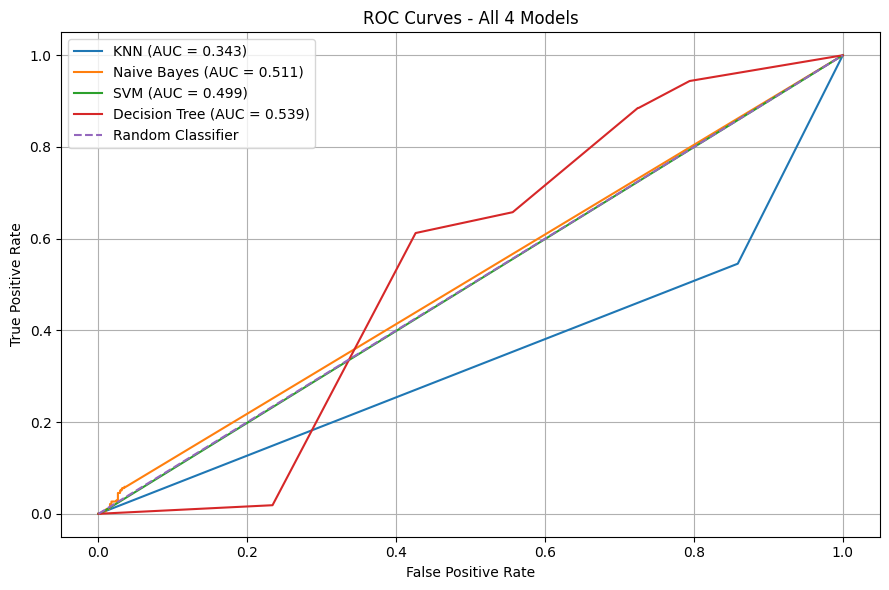

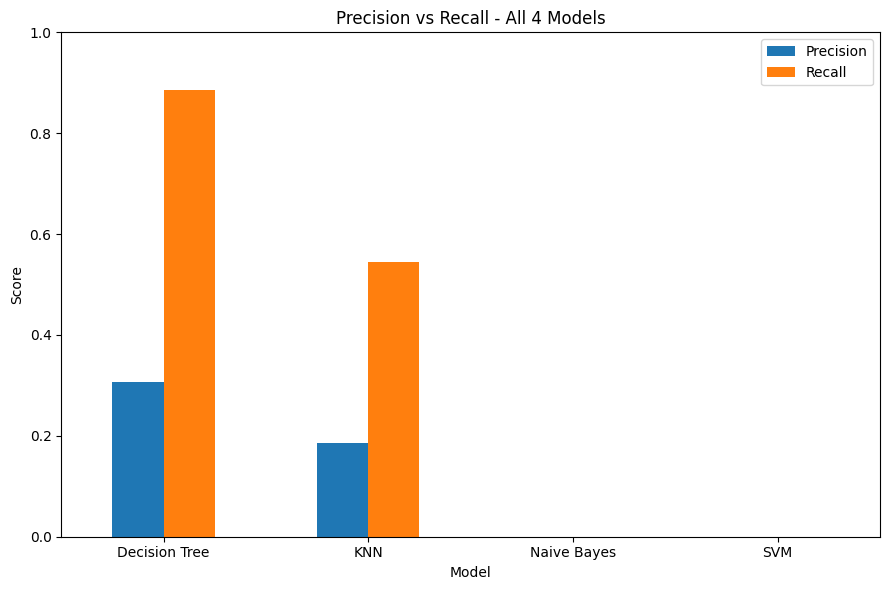

Best Model: Decision Tree
Recall: 0.885
Precision: 0.3062
F1-Score: 0.455
AUC-ROC: 0.539


In [117]:
# Step 6: Model Evaluation & Comparison

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)



# 1. Create all 4 models

models = {
    "KNN": KNeighborsClassifier(n_neighbors=best_k),

    "Naive Bayes": GaussianNB(),

    "SVM": SVC(
        kernel="rbf",
        C=best_C,
        gamma="scale",
        probability=True,
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=best_depth,
        class_weight="balanced",
        random_state=42
    )
}



# 2. Train and evaluate models


results = []

for name, model in models.items():

    # Start timer
    start_time = time.time()

    # Train model
    model.fit(
        X_train_smote,
        y_train_smote
    )

    # Training time
    training_time = time.time() - start_time

    # Prediction
    y_pred = model.predict(X_test)

    # Probability
    y_prob = model.predict_proba(X_test)[:, 1]

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        pos_label=1
    )

    recall = recall_score(
        y_test,
        y_pred,
        pos_label=1
    )

    f1 = f1_score(
        y_test,
        y_pred,
        pos_label=1
    )

    auc = roc_auc_score(
        y_test,
        y_prob
    )

    # Store results
    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1,
        "AUC-ROC": auc,
        "Training Time (seconds)": training_time
    })


# 3. Create comparison DataFrame

comparison = pd.DataFrame(results)

# Sort by Recall descending
comparison = comparison.sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)


# Display formatted table
print("MODEL COMPARISON")
display(comparison.round(4))


# 4. ROC CURVES - ALL 4 MODELS

plt.figure(figsize=(9, 6))

for name, model in models.items():

    y_prob = model.predict_proba(X_test)[:, 1]

    fpr, tpr, _ = roc_curve(
        y_test,
        y_prob
    )

    auc_score = roc_auc_score(
        y_test,
        y_prob
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )


# Random classifier
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All 4 Models")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

# 5. Precision vs Recall — Grouped Bar Chart

# PRECISION vs RECALL
comparison.plot(
    x="Model",
    y=["Precision", "Recall"],
    kind="bar",
    figsize=(9, 6)
)

plt.title("Precision vs Recall - All 4 Models")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1)

plt.xticks(rotation=0)
plt.legend()

plt.tight_layout()
plt.show()

# 6. Automatically Find Best Model

# BEST MODEL BASED ON RECALL
best_model_row = comparison.iloc[0]

print("Best Model:", best_model_row["Model"])
print("Recall:", round(best_model_row["Recall"], 4))
print("Precision:", round(best_model_row["Precision"], 4))
print("F1-Score:", round(best_model_row["F1-Score"], 4))
print("AUC-ROC:", round(best_model_row["AUC-ROC"], 4))

In [ ]:
# Step 7: Error Analysis & Interpretation

# Step 7.1.1 — Best Model ki Prediction

# 7.1.1 Error Analysis on Best Model
# Find best model based on highest Recall
best_model = comparison.loc[
    comparison["Recall"].idxmax(),
    "Model"
]

print("Best Model:", best_model)

# Prediction using best model
y_pred_best = models[best_model].predict(X_test)

print("Prediction completed successfully!")



# Step 7.1.2 — False Negatives Identify Karein
# Find False Negatives
fn_mask = (y_test == 1) & (y_pred_best == 0)

print("Total False Negatives:", fn_mask.sum())


# Step 7.1.3 — False Negative Customers

# Get False Negative indexes
fn_indices = X_test.index[fn_mask]

# Create False Negative data
fn_customers = df.loc[
    fn_indices,
    ["tenure", "MonthlyCharges"]
].copy()

# Add Contract from dummy columns
contract_columns = [
    "Contract_Month-to-month",
    "Contract_One year",
    "Contract_Two year"
]

# Check which contract columns exist
existing_contracts = [
    col for col in contract_columns
    if col in df.columns
]

if len(existing_contracts) > 0:

    fn_customers["Contract"] = (
        df.loc[fn_indices, existing_contracts]
        .idxmax(axis=1)
        .str.replace("Contract_", "", regex=False)
    )

print("False Negative Customers:")
display(fn_customers.head())


# Step 7.1.4 — False Negative Profile

# Average profile of False Negatives
print("False Negative Profile")

print("Average Tenure:",
      round(fn_customers["tenure"].mean(), 2))

print("Average MonthlyCharges:",
      round(fn_customers["MonthlyCharges"].mean(), 2))

print("\nContract Type:")
print(fn_customers["Contract"].value_counts())



# Step 7.1.5 — Overall Churner Profile

# Overall churners
churners = df[df["Churn"] == 1].copy()

print("Overall Churner Profile")

# Average Tenure
print(
    "Average Tenure:",
    round(churners["tenure"].mean(), 2)
)

# Average Monthly Charges
print(
    "Average MonthlyCharges:",
    round(churners["MonthlyCharges"].mean(), 2)
)

# Contract Type
print("\nContract Type:")

contract_columns = [
    "Contract_Month-to-month",
    "Contract_One year",
    "Contract_Two year"
]

# Only columns that actually exist
existing_contracts = [
    col for col in contract_columns
    if col in df.columns
]

if existing_contracts:

    contract_data = churners[existing_contracts]

    contract_type = (
        contract_data
        .idxmax(axis=1)
        .str.replace("Contract_", "", regex=False)
    )

    print(contract_type.value_counts())

else:
    print("Contract dummy columns not found.")


# Step 7.1.6 — Percentage Comparison

# Contract dummy columns
contract_columns = [
    "Contract_Month-to-month",
    "Contract_One year",
    "Contract_Two year"
]

# Find existing columns
existing_contracts = [
    col for col in contract_columns
    if col in df.columns
]

# False Negatives Contract


fn_contract_data = df.loc[
    fn_customers.index,
    existing_contracts
]

fn_contract_type = (
    fn_contract_data
    .idxmax(axis=1)
    .str.replace("Contract_", "", regex=False)
)

print("False Negatives - Contract %")
print(
    fn_contract_type
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)



# Overall Churners Contract


churner_contract_data = churners[
    existing_contracts
]

churner_contract_type = (
    churner_contract_data
    .idxmax(axis=1)
    .str.replace("Contract_", "", regex=False)
)

print("\nOverall Churners - Contract %")
print(
    churner_contract_type
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

# Step 7.1.7 — Error Analysis Pattern

print("What pattern do you notice?\n")

print(
    "False Negatives have higher average tenure:",
    round(fn_customers["tenure"].mean(), 2),
    "vs",
    round(churners["tenure"].mean(), 2),
    "months for overall churners."
)

print(
    "False Negatives have lower average MonthlyCharges:",
    round(fn_customers["MonthlyCharges"].mean(), 2),
    "vs",
    round(churners["MonthlyCharges"].mean(), 2),
    "for overall churners."
)

# Contract percentages
fn_contract_pct = (
    fn_contract_type
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

churner_contract_pct = (
    churner_contract_type
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nFalse Negatives Contract %:")
print(fn_contract_pct)

print("\nOverall Churners Contract %:")
print(churner_contract_pct)

print("\nConclusion:")
print(
    "The model mainly misses churners with longer tenure "
    "and lower MonthlyCharges. Most missed customers have "
    "one-year contracts, similar to the overall churner group."
)

Best Model: Decision Tree
Prediction completed successfully!
Total False Negatives: 43
False Negative Customers:


,tenure,MonthlyCharges,Contract
1577,17,98.60,One year
2361,1,45.95,One year
1014,18,57.45,One year
3831,25,89.05,One year
3357,1,59.20,One year


False Negative Profile
Average Tenure: 25.33
Average MonthlyCharges: 67.87

Contract Type:
Contract
One year    41
Two year     2
Name: count, dtype: int64
Overall Churner Profile
Average Tenure: 17.98
Average MonthlyCharges: 74.44

Contract Type:
One year    1821
Two year      48
Name: count, dtype: int64
False Negatives - Contract %
One year    95.35
Two year     4.65
Name: proportion, dtype: float64

Overall Churners - Contract %
One year    97.43
Two year     2.57
Name: proportion, dtype: float64
What pattern do you notice?

False Negatives have higher average tenure: 25.33 vs 17.98 months for overall churners.
False Negatives have lower average MonthlyCharges: 67.87 vs 74.44 for overall churners.

False Negatives Contract %:
One year    95.35
Two year     4.65
Name: proportion, dtype: float64

Overall Churners Contract %:
One year    97.43
Two year     2.57
Name: proportion, dtype: float64

Conclusion:
The model mainly misses churners with longer tenure and lower MonthlyCharges. M

Top 5 Decision Tree Split Features:

1. Contract_Two year
   Importance: 0.3430
   Meaning: This feature is important for predicting whether a customer will churn or not.

2. Contract_One year
   Importance: 0.2456
   Meaning: This feature is important for predicting whether a customer will churn or not.

3. tenure
   Importance: 0.0987
   Meaning: This feature is important for predicting whether a customer will churn or not.

4. InternetService_Fiber optic
   Importance: 0.0790
   Meaning: This feature is important for predicting whether a customer will churn or not.

5. MonthlyCharges
   Importance: 0.0749
   Meaning: This feature is important for predicting whether a customer will churn or not.

Top 5 Features Table:


,Feature,Importance
0,Contract_Two year,0.342986
1,Contract_One year,0.245571
2,tenure,0.098695
3,InternetService_Fiber optic,0.079021
4,MonthlyCharges,0.074861



Business-Friendly Decision Insights:

• Contract_Two year is one of the most important factors in predicting customer churn, with an importance score of 0.3430.
• Contract_One year is one of the most important factors in predicting customer churn, with an importance score of 0.2456.
• tenure is one of the most important factors in predicting customer churn, with an importance score of 0.0987.
• InternetService_Fiber optic is one of the most important factors in predicting customer churn, with an importance score of 0.0790.
• MonthlyCharges is one of the most important factors in predicting customer churn, with an importance score of 0.0749.

Key Business Insights:
• Contract_Two year is the most important feature used by the Decision Tree for churn prediction.
• Contract_One year is another important factor that helps identify customers who may be at higher risk of churn.
• tenure provides additional information for distinguishing customers who are likely to churn.
• InternetService_F

,Feature,Importance
0,SeniorCitizen,0.0
1,Partner,0.0
2,Dependents,0.0
3,tenure,0.0
4,PhoneService,0.0
5,PaperlessBilling,0.0
6,MonthlyCharges,0.0
7,TotalCharges,0.0
8,tenure_group,0.0
9,num_services,0.0


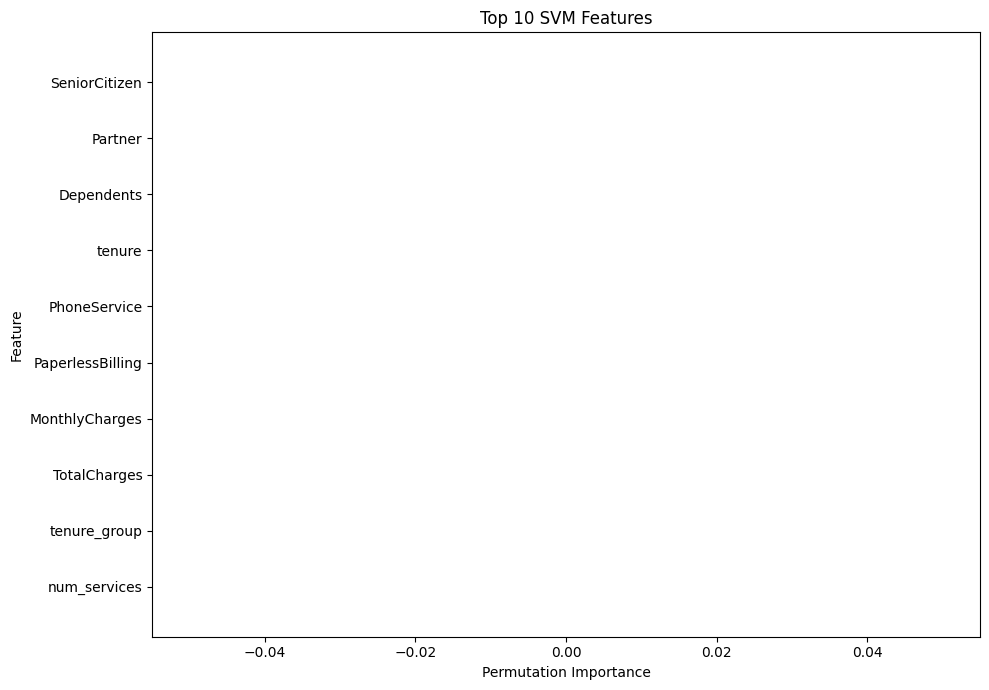

In [119]:
# 7.2.1 Top 5 Split Features and Explanation

# Get feature importance
importance = final_dt.feature_importances_

# Get correct feature names
if hasattr(final_dt, "feature_names_in_"):
    feature_names = final_dt.feature_names_in_

elif len(X_train.columns) == len(importance):
    feature_names = X_train.columns

else:
    feature_names = [f"Feature_{i+1}" for i in range(len(importance))]

# Create Feature Importance DataFrame
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Top 5 features
top_5 = feature_importance.head(5)

# Print results
print("Top 5 Decision Tree Split Features:\n")

for i, row in top_5.iterrows():
    print(f"{i+1}. {row['Feature']}")
    print(f"   Importance: {row['Importance']:.4f}")
    print(
        "   Meaning: This feature is important for predicting "
        "whether a customer will churn or not.\n"
    )

# Display table
print("Top 5 Features Table:")
display(top_5)


# 7.2.2 Business-Friendly Decision Insights

print("\nBusiness-Friendly Decision Insights:\n")

for i, row in top_5.iterrows():
    
    feature = row["Feature"]
    importance = row["Importance"]
    
    print(
        f"• {feature} is one of the most important factors in "
        f"predicting customer churn, with an importance score of "
        f"{importance:.4f}."
    )

print("\nKey Business Insights:")

print(
    f"• {top_5.iloc[0]['Feature']} is the most important feature "
    "used by the Decision Tree for churn prediction."
)

print(
    f"• {top_5.iloc[1]['Feature']} is another important factor "
    "that helps identify customers who may be at higher risk of churn."
)

print(
    f"• {top_5.iloc[2]['Feature']} provides additional information "
    "for distinguishing customers who are likely to churn."
)

print(
    f"• {top_5.iloc[3]['Feature']} contributes to the Decision Tree's "
    "churn prediction and can support customer retention decisions."
)

print(
    f"• {top_5.iloc[4]['Feature']} is also useful for identifying "
    "customers who may need targeted retention strategies."
)

# 7.2.3 Optional Bonus - SVM Permutation Importance

from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Calculate permutation importance
perm_result = permutation_importance(
    svm_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="accuracy"
)

# Get feature names
if hasattr(svm_model, "feature_names_in_"):
    feature_names = svm_model.feature_names_in_
elif len(X_test.columns) == len(perm_result.importances_mean):
    feature_names = X_test.columns
else:
    feature_names = [
        f"Feature_{i+1}"
        for i in range(len(perm_result.importances_mean))
    ]

# Create DataFrame
svm_feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": perm_result.importances_mean
})

# Sort by importance
svm_feature_importance = svm_feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

# Top 10 features
top_10_svm = svm_feature_importance.head(10)

# Print Top 10
print("Top 10 SVM Features:\n")

for i, row in top_10_svm.iterrows():
    print(
        f"{i+1}. {row['Feature']} "
        f"-> Importance: {row['Importance']:.4f}"
    )

# Display table
print("\nTop 10 SVM Feature Importance Table:")
display(top_10_svm)

# Top 10 SVM Features Plot

plt.figure(figsize=(10, 7))

plt.barh(
    top_10_svm["Feature"],
    top_10_svm["Importance"]
)

plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 10 SVM Features")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [120]:
# 8.1  Save the Final Pipeline

# --------------------------------
# 1. Create X and y from original df
# --------------------------------

X_original = df.drop("Churn", axis=1)
y_original = df["Churn"]

# --------------------------------
# 2. Train-Test Split
# --------------------------------

X_train_original, X_test_original, y_train_original, y_test_original = train_test_split(
    X_original,
    y_original,
    test_size=0.20,
    random_state=42,
    stratify=y_original
)

# --------------------------------
# 3. Identify columns
# --------------------------------

numeric_cols = X_train_original.select_dtypes(
    include=["int64", "float64"]
).columns

categorical_cols = X_train_original.select_dtypes(
    include=["object"]
).columns

# --------------------------------
# 4. Create Preprocessor
# --------------------------------

preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"),
         categorical_cols)
    ]
)

# --------------------------------
# 5. Create Pipeline
# --------------------------------
# Best model + Preprocessor
pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", final_dt)
])




# --------------------------------
# 6. Train Pipeline
# --------------------------------

pipeline.fit(
    X_train_original,
    y_train_original
)

print("Pipeline created and trained successfully!")

# --------------------------------
# 7. Save Pipeline
# --------------------------------

joblib.dump(
    pipeline,
    "churn_model.pkl"
)

print("Pipeline saved successfully!")

# --------------------------------
# 8. Load Pipeline
# --------------------------------

loaded_pipeline = joblib.load(
    "churn_model.pkl"
)

print("Pipeline loaded successfully!")

# --------------------------------
# 9. Select 5 Original Customers
# --------------------------------

sample_customers = X_test_original.iloc[:5]

# --------------------------------
# 10. Predict Probability
# --------------------------------

probabilities = loaded_pipeline.predict_proba(
    sample_customers
)[:, 1]

# --------------------------------
# 11. Predict Final Label
# --------------------------------

predictions = loaded_pipeline.predict(
    sample_customers
)

# --------------------------------
# 12. Print Results
# --------------------------------

print("\nChurn Prediction for 5 Customers:\n")

for i in range(5):

    print(f"Customer {i + 1}")
    print(
        "Predicted Probability:",
        round(probabilities[i], 4)
    )

    print(
        "Final Label:",
        "Churn" if predictions[i] == 1
        else "No Churn"
    )

    print("-" * 40)

Pipeline created and trained successfully!
Pipeline saved successfully!
Pipeline loaded successfully!

Churn Prediction for 5 Customers:

Customer 1
Predicted Probability: 0.0
Final Label: No Churn
----------------------------------------
Customer 2
Predicted Probability: 0.908
Final Label: Churn
----------------------------------------
Customer 3
Predicted Probability: 0.1676
Final Label: No Churn
----------------------------------------
Customer 4
Predicted Probability: 0.6528
Final Label: Churn
----------------------------------------
Customer 5
Predicted Probability: 0.0
Final Label: No Churn
----------------------------------------
